<a href="https://colab.research.google.com/github/jonathancagua/audio/blob/main/audio_cuanti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Este conjunto de datos recopila cantos de cinco especies de aves (Cucarachero de Bewick, Cardenal Norteño, Robin Americano, Gorrión Melódico y Cenzontle Norteño) con el objetivo de entrenar modelos de identificación a partir de grabaciones de 3 segundos. Los audios, extraídos de la plataforma xeno-canto, están estandarizados en formato wav (22050 Hz, mono) y se incluyen en un archivo CSV con metadatos asociados. Puede explorar el conjunto de datos completo en [Kaggle](
https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set)

In [22]:
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.model_selection import train_test_split
import keras
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from keras.callbacks import TensorBoard, ModelCheckpoint
import seaborn as sns

In [23]:
!pip install kaggle

In [24]:
!kaggle datasets download -d vinayshanbhag/bird-song-data-set --unzip -p ./bird-data



Dataset URL: https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set
License(s): other
100% 2.09G/2.09G [00:37<00:00, 59.6MB/s]



In [25]:
import os

DATA_DIR = "/content/bird-data"
metadata = pd.read_csv(f"{DATA_DIR}/bird_songs_metadata.csv")

label_dict = {
    'bewickii': 0, 'polyglottos': 1, 'migratorius': 2,
    'melodia': 3, 'cardinalis': 4
}
bird_labels = metadata['species'].map(label_dict).values

bird_filepaths = (DATA_DIR + "/wavfiles/" + metadata['filename']).values

bird_filepaths_train, bird_filepaths_val, bird_labels_train, bird_labels_val = train_test_split(
    bird_filepaths, bird_labels, test_size=0.10, random_state=2419
)


In [26]:
# Constantes globales de preprocesado
SR = 22050
DURATION = 3
NUM_SAMPLES = SR * DURATION  # 66150

FRAME_LENGTH = 512
FRAME_STEP = 64

TIME_FRAMES = 1026
FREQ_BINS = 257


def load_audio_fixed(path):
    # Carga robusta: WAV mono + SR fijo + longitud fija
    path_bytes = path.numpy()
    path_string = path_bytes.decode('utf-8') if isinstance(path_bytes, (bytes, bytearray)) else str(path_bytes)

    try:
        y, _ = librosa.load(path_string, sr=SR, mono=True)
    except Exception:
        # Si falla la lectura, devolvemos silencio para no romper el pipeline
        y = np.zeros((0,), dtype=np.float32)

    if y.shape[0] > NUM_SAMPLES:
        y = y[:NUM_SAMPLES]
    elif y.shape[0] < NUM_SAMPLES:
        y = np.pad(y, (0, NUM_SAMPLES - y.shape[0]), mode='constant')

    return y.astype(np.float32)


def map_function_fixed(path_tensor, label):
    y = tf.py_function(load_audio_fixed, [path_tensor], tf.float32)
    y.set_shape([NUM_SAMPLES])

    # 1. STFT (shape fijo por longitud fija de audio)
    stft = tf.signal.stft(
        y,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FRAME_LENGTH,
        pad_end=False
    )
    spectrogram = tf.abs(stft)

    # 2. dB con logaritmo base 10 (misma lógica actual)
    log10_spec = tf.math.log(spectrogram + 1e-6) / tf.math.log(10.0)
    spectrogram_db = 20.0 * log10_spec - 20.0 * (tf.math.log(100.0) / tf.math.log(10.0))

    # 3. Normalización a rango [0, 1]
    spectrogram_norm = (spectrogram_db + 80.0) / 80.0
    spectrogram_norm = tf.clip_by_value(spectrogram_norm, 0.0, 1.0)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS])

    return spectrogram_norm, label


def map_function_fixed_4d(path_tensor, label):
    # Variante para exportación futura (canal al final)
    spectrogram_norm, label = map_function_fixed(path_tensor, label)
    spectrogram_norm = tf.expand_dims(spectrogram_norm, axis=-1)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS, 1])
    return spectrogram_norm, label


In [27]:
def make_dataset(labels, filepaths, shuffle=False, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    dataset = dataset.map(map_function_fixed, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size, drop_remainder=True)

    return dataset.prefetch(tf.data.AUTOTUNE)


In [28]:
dataset_train = make_dataset(bird_labels_train, bird_filepaths_train, shuffle=True)
dataset_val = make_dataset(bird_labels_val, bird_filepaths_val, shuffle=False)


Shape batch espectrograma (train): (32, 1026, 257)
Shape batch labels (train): (32,)
Shape espectrograma 4D (1 muestra): (1026, 257, 1)


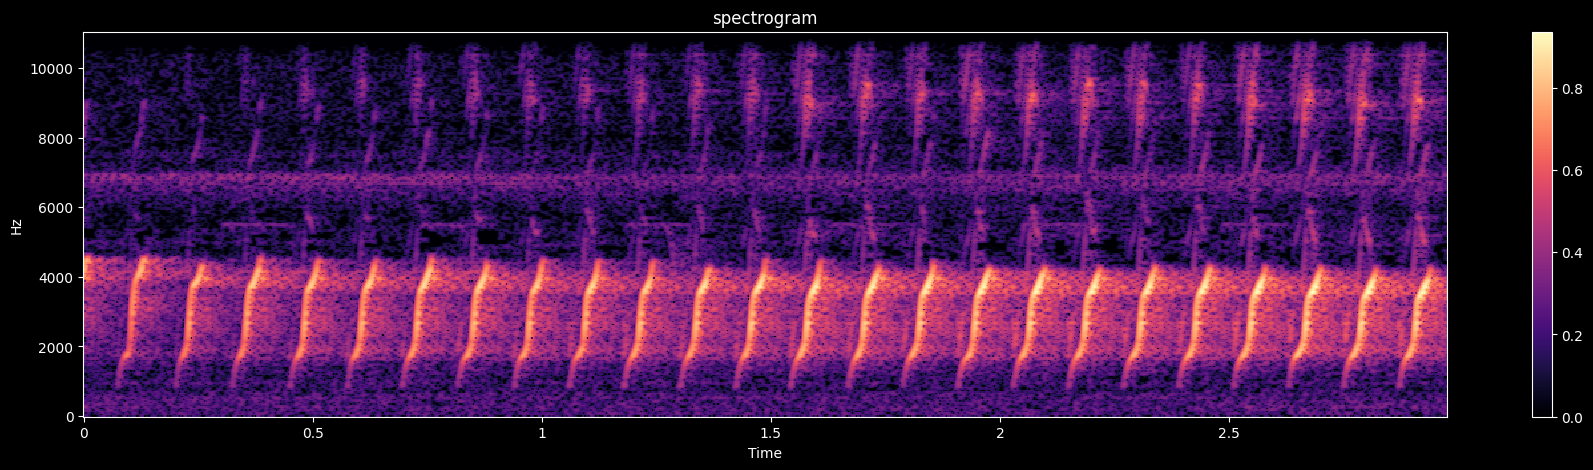

In [29]:
for spectrograms, labels in dataset_train.take(1):
    print('Shape batch espectrograma (train):', spectrograms.shape)
    print('Shape batch labels (train):', labels.shape)

    spec_4d, _ = map_function_fixed_4d(
        tf.constant(bird_filepaths_train[0]),
        tf.constant(bird_labels_train[0])
    )
    print('Shape espectrograma 4D (1 muestra):', spec_4d.shape)

    plt.figure(figsize=(22, 5))
    librosa.display.specshow(
        spectrograms[0].numpy().T,
        sr=22050,
        hop_length=64,
        n_fft=512,
        y_axis='linear',
        x_axis='time',
        cmap='magma'
    )
    plt.colorbar()
    plt.title('spectrogram')
    plt.show()

In [30]:
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D, BatchNormalization

def create_model():
    inputs = Input(shape=(TIME_FRAMES, FREQ_BINS), name='0_Input_shape')

    # Bloque 1
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='1_Conv1D')(inputs)
    x = BatchNormalization()(x) # Agregado: Estabiliza el entrenamiento
    x = SpatialDropout1D(0.17, name='2_SpatialDropout1D')(x)

    # Bloque 2
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='3_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='4_SpatialDropout1D')(x)

    # Bloque 3
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='5_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='6_SpatialDropout1D')(x)

    # Bloque 4
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='7_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='8_SpatialDropout1D')(x)

    # Reducción y Clasificación
    x = GlobalAveragePooling1D(name='9_Global_avg_pooling')(x)
    x = Dense(512, activation='relu', name='10_Dense')(x)
    x = Dropout(0.5, name='11_Dropout')(x)

    # activation='softmax'
    outputs = Dense(5, activation='softmax', name='12_Output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Bird_audio_classification_model')
    return model


In [31]:
# Instanciar y compilar
model = create_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "Bird_audio_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0_Input_shape (InputLayer)      │ (None, 1026, 257)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1_Conv1D (Conv1D)               │ (None, 513, 128)       │       263,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 513, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2_SpatialDropout1D              │ (None, 513, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3_Conv1d (Conv1D)               │ (None, 257, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 257, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4_SpatialDropout1D              │ (None, 257, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5_Conv1d (Conv1D)               │ (None, 129, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 129, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 6_SpatialDropout1D              │ (None, 129, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 7_Conv1d (Conv1D)               │ (None, 65, 128)        │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 8_SpatialDropout1D              │ (None, 65, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 9_Global_avg_pooling            │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 10_Dense (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 11_Dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 12_Output (Dense)               │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,557 (2.78 MB)

 Trainable params: 726,533 (2.77 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [33]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import os

logdir = 'tb_logs/modelo_final'

checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_pajaros.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tb_callback = TensorBoard(log_dir=logdir)

history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    callbacks=[checkpoint, early_stop, tb_callback]
)


Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.4090 - loss: 1.3488
Epoch 1: val_accuracy improved from None to 0.55664, saving model to mejor_modelo_pajaros.keras

Epoch 1: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 61s 282ms/step - accuracy: 0.4766 - loss: 1.2049 - val_accuracy: 0.5566 - val_loss: 1.0689
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5674 - loss: 1.0250
Epoch 2: val_accuracy improved from 0.55664 to 0.59180, saving model to mejor_modelo_pajaros.keras

Epoch 2: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 186ms/step - accuracy: 0.5849 - loss: 0.9895 - val_accuracy: 0.5918 - val_loss: 1.0330
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6269 - loss: 0.9043
Epoch 3: val_accuracy improved from 0.59180 to 0.59766, saving model to mejor_modelo_pajaros.keras

Epoch 3: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━

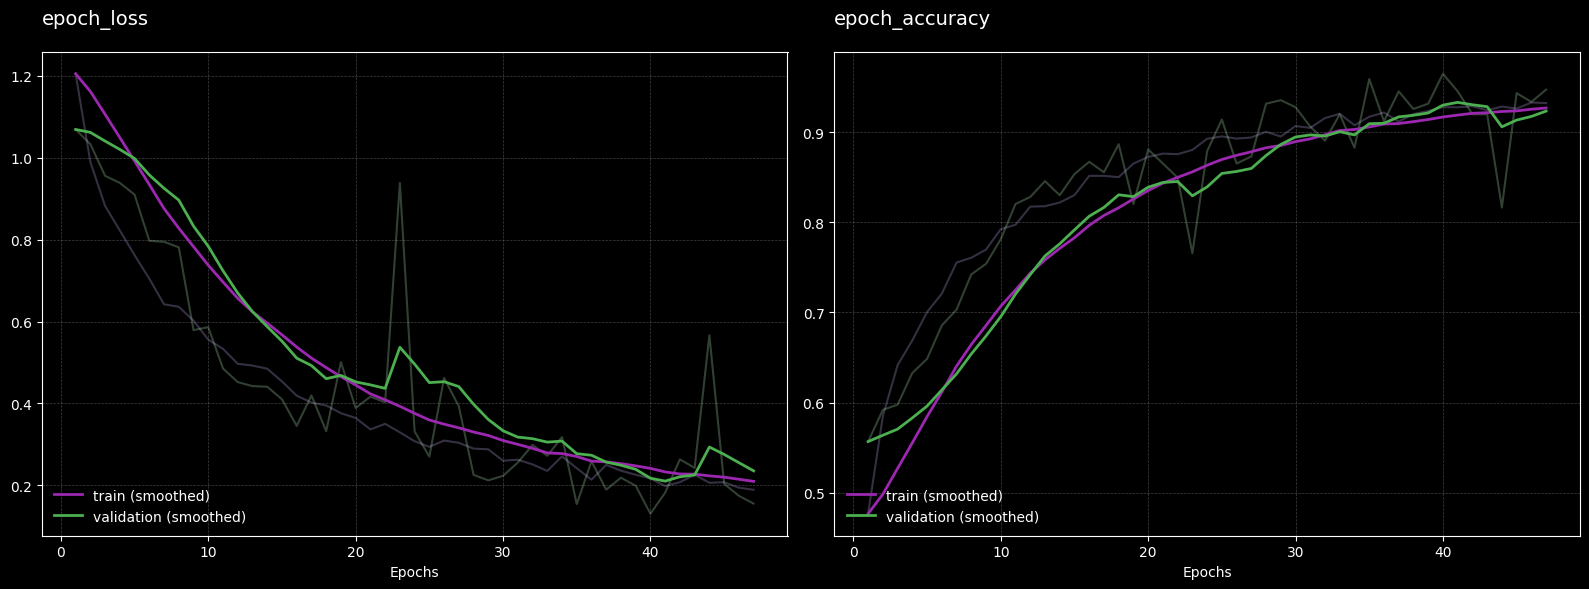

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tensorboard_style(history):
    plt.style.use('dark_background')

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    def smooth_curve(points, factor=0.8):
        smoothed_points = []
        for point in points:
            if smoothed_points:
                previous = smoothed_points[-1]
                smoothed_points.append(previous * factor + point * (1 - factor))
            else:
                smoothed_points.append(point)
        return smoothed_points

    plt.figure(figsize=(16, 6))

    # --- Gráfico de Pérdida (Loss) ---
    plt.subplot(1, 2, 1)
    # Líneas tenues (datos reales)
    plt.plot(epochs, loss, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_loss, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas (suavizadas)
    plt.plot(epochs, smooth_curve(loss), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_loss), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_loss', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    # --- Gráfico de Precisión (Accuracy) ---
    plt.subplot(1, 2, 2)
    # Líneas tenues
    plt.plot(epochs, acc, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_acc, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas
    plt.plot(epochs, smooth_curve(acc), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_acc), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_accuracy', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    plt.tight_layout()
    plt.show()

plot_tensorboard_style(history)



In [35]:
model_eval = tf.keras.models.load_model('mejor_modelo_pajaros.keras')

results = model_eval.evaluate(dataset_val, return_dict=True)

print("\n--- Resultados de la Evaluación ---")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.9648 - loss: 0.1308

--- Resultados de la Evaluación ---
accuracy: 0.9648
loss: 0.1308


In [36]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

print("Generando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_pred = tf.argmax(y_logits, axis=1).numpy()

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=bird_names))



Generando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    bewickii       0.95      0.97      0.96        86
 polyglottos       0.98      0.96      0.97       112
 migratorius       0.97      0.98      0.97        88
     melodia       0.98      0.95      0.96       128
  cardinalis       0.94      0.98      0.96        98

    accuracy                           0.96       512
   macro avg       0.96      0.97      0.96       512
weighted avg       0.97      0.96      0.96       512



In [37]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print("Calculando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_prob = tf.nn.softmax(y_logits, axis=1).numpy()

y_pred = np.argmax(y_logits, axis=1)

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

f1 = f1_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
auc = roc_auc_score(y_true, y_prob, average='macro', multi_class='ovo')

# Imprimir resultados
print("-" * 30)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC ROC:   {auc:.4f}")
print("-" * 30)



Calculando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step
------------------------------
F1 Score:  0.9648
Precision: 0.9638
Recall:    0.9661
AUC ROC:   0.9971
------------------------------


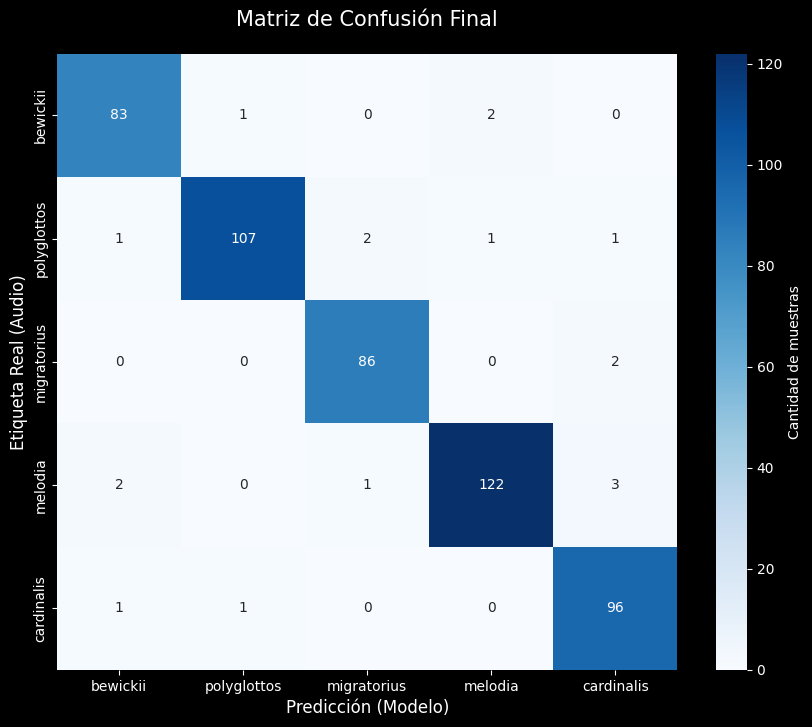

In [38]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=bird_names,
            yticklabels=bird_names,
            annot=True,
            fmt='g',
            cmap='Blues', # O 'magma' si quieres el estilo de antes
            cbar_kws={'label': 'Cantidad de muestras'})

plt.title('Matriz de Confusión Final', fontsize=15, pad=20)
plt.xlabel('Predicción (Modelo)', fontsize=12)
plt.ylabel('Etiqueta Real (Audio)', fontsize=12)
plt.show()


In [39]:
!pip -q install tensorflow-model-optimization

In [40]:
import os
import time
import tempfile
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import tensorflow_model_optimization as tfmot

In [41]:
def collect_y_true(dataset):
    y_true = []
    for _, y in dataset:
        y_true.extend(y.numpy())
    return np.array(y_true)

def get_keras_model_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".keras", delete=False) as tmp:
        tmp_path = tmp.name
    model.save(tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

def representative_data_gen():
    # Usa muestras reales del pipeline ya preprocesado
    for x, _ in dataset_train.unbatch().take(100):
        x = tf.expand_dims(x, axis=0)
        yield [tf.cast(x, tf.float32)]

def evaluate_keras_model(model, dataset, model_name="keras_fp32"):
    y_true = collect_y_true(dataset)

    t0 = time.perf_counter()
    y_prob = model.predict(dataset, verbose=0)
    elapsed = time.perf_counter() - t0

    y_pred = np.argmax(y_prob, axis=1)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "auc_ovo_macro": roc_auc_score(y_true, y_prob, average="macro", multi_class="ovo"),
        "size_mb": get_keras_model_size_mb(model),
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true)) * 1000
    }

def convert_to_tflite(keras_model, quant_mode="dynamic"):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if quant_mode == "dynamic":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    elif quant_mode == "float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_mode == "int8":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    else:
        raise ValueError(f"Modo no soportado: {quant_mode}")

    return converter.convert()


def evaluate_tflite_model(tflite_model, dataset, model_name):
    import time
    import numpy as np
    import tensorflow as tf
    from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

    try:
        from ai_edge_litert.interpreter import Interpreter
        interpreter = Interpreter(model_content=tflite_model)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_content=tflite_model)

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    in_detail = input_details[0]
    out_detail = output_details[0]

    in_dtype = in_detail["dtype"]
    out_dtype = out_detail["dtype"]

    # TFLite recomienda quantization_parameters; tomamos el primer scale/zero_point
    in_qparams = in_detail.get("quantization_parameters", {})
    out_qparams = out_detail.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0

    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    all_preds = []
    all_labels = []

    t0 = time.perf_counter()

    for images, labels in dataset:
        imgs_np = images.numpy() if hasattr(images, "numpy") else np.asarray(images)
        lbls_np = labels.numpy() if hasattr(labels, "numpy") else np.asarray(labels)

        for i in range(len(imgs_np)):
            x = np.expand_dims(imgs_np[i], axis=0).astype(np.float32)

            # Cuantizar entrada solo si el modelo lo requiere
            if in_dtype == np.int8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, -128, 127).astype(np.int8)
            elif in_dtype == np.uint8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, 0, 255).astype(np.uint8)
            else:
                x = x.astype(in_dtype)

            interpreter.set_tensor(in_detail["index"], x)
            interpreter.invoke()

            y = interpreter.get_tensor(out_detail["index"])

            # Descuantizar salida si hace falta
            if out_dtype == np.int8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            elif out_dtype == np.uint8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            else:
                y = y.astype(np.float32)

            all_preds.append(y.flatten())
            all_labels.append(lbls_np[i])

    elapsed = time.perf_counter() - t0

    all_preds = np.vstack(all_preds).astype(np.float64)
    all_labels = np.array(all_labels)

    # Si las salidas no parecen probabilidades, aplicar softmax
    row_sums = all_preds.sum(axis=1, keepdims=True)
    if np.any(all_preds < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(all_preds - np.max(all_preds, axis=1, keepdims=True))
        all_preds = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)

    # Etiquetas: soporta sparse o one-hot
    if all_labels.ndim > 1:
        y_true_labels = np.argmax(all_labels, axis=1)
        y_true_auc = all_labels
    else:
        y_true_labels = all_labels
        num_classes = all_preds.shape[1]
        y_true_auc = np.eye(num_classes)[y_true_labels]

    y_pred_labels = np.argmax(all_preds, axis=1)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "f1_macro": f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "size_kb": len(tflite_model) / 1024,
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true_labels)) * 1000
    }

    try:
        result["auc_ovo_macro"] = roc_auc_score(
            y_true_auc, all_preds, average="macro", multi_class="ovo"
        )
    except ValueError:
        result["auc_ovo_macro"] = np.nan

    return result




In [42]:
import numpy as np
import pandas as pd

def safe_evaluate_tflite(tflite_model, dataset, model_name):
    """
    Versión robusta de evaluación que normaliza las salidas
    para que sumen 1.0, evitando errores en sklearn.
    """
    return evaluate_tflite_model(tflite_model, dataset, model_name)

results = []

results.append(evaluate_keras_model(model_eval, dataset_val, model_name="baseline_fp32"))

tflite_dynamic = convert_to_tflite(model_eval, quant_mode="dynamic")
results.append(evaluate_tflite_model(tflite_dynamic, dataset_val, model_name="ptq_dynamic"))

tflite_float16 = convert_to_tflite(model_eval, quant_mode="float16")
results.append(evaluate_tflite_model(tflite_float16, dataset_val, model_name="ptq_float16"))

tflite_int8 = convert_to_tflite(model_eval, quant_mode="int8")
results.append(evaluate_tflite_model(tflite_int8, dataset_val, model_name="ptq_int8"))

results_df = pd.DataFrame(results)
display(results_df)


Saved artifact at '/tmp/tmpdqav5swt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135137199323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199319056

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmpd7o5ha16'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135137199323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199319056

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmp8hvr2_ry'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135137199323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199319056

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_mb,latency_total_s,latency_per_sample_ms,size_kb
0,baseline_fp32,0.964844,0.964808,0.963829,0.966093,0.997019,8.397452,4.862388,9.496852,NaN
1,ptq_dynamic,0.964844,0.964808,0.963829,0.966093,0.997010,NaN,9.938354,19.410847,741.171875
2,ptq_float16,0.964844,0.964808,0.963829,0.966093,0.997006,NaN,10.284987,20.087865,1435.167969
3,ptq_int8,0.958984,0.958703,0.957714,0.959993,0.996167,NaN,10.249749,20.019041,751.554688


In [43]:
def convert_to_tflite_fp32(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    return converter.convert()

tflite_fp32 = convert_to_tflite_fp32(model_eval)

Saved artifact at '/tmp/tmp9e22gmnj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135137199323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199319056

In [44]:
import time
import numpy as np
import tensorflow as tf
import tracemalloc
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

def dataset_to_numpy(dataset, max_samples=None):
    xs, ys = [], []
    count = 0
    for batch_x, batch_y in dataset:
        x_np = batch_x.numpy()
        y_np = batch_y.numpy()

        for i in range(len(x_np)):
            xs.append(x_np[i])
            ys.append(y_np[i])
            count += 1
            if max_samples is not None and count >= max_samples:
                return np.array(xs), np.array(ys)
    return np.array(xs), np.array(ys)


def create_tflite_interpreter(model_content):
    try:
        from ai_edge_litert.interpreter import Interpreter
        interpreter = Interpreter(model_content=model_content)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_content=model_content)

    interpreter.allocate_tensors()
    return interpreter


def run_single_inference(interpreter, x):
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_dtype = input_details["dtype"]
    out_dtype = output_details["dtype"]

    in_qparams = input_details.get("quantization_parameters", {})
    out_qparams = output_details.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0
    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    x = np.expand_dims(x, axis=0).astype(np.float32)

    if in_dtype == np.int8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, -128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        x = np.round(x / in_scale + in_zero)
        x = np.clip(x, 0, 255).astype(np.uint8)
    else:
        x = x.astype(in_dtype)

    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()
    y = interpreter.get_tensor(output_details["index"])

    if out_dtype == np.int8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    elif out_dtype == np.uint8:
        y = (y.astype(np.float32) - out_zero) * out_scale
    else:
        y = y.astype(np.float32)

    return y.flatten()


def benchmark_tflite_model(model_content, x_data, y_true, model_name, warmup=10, benchmark_runs=100):
    interpreter = create_tflite_interpreter(model_content)

    # Warmup
    for i in range(min(warmup, len(x_data))):
        _ = run_single_inference(interpreter, x_data[i])

    # Benchmark de 100 inferencias
    times = []
    tracemalloc.start()

    for i in range(min(benchmark_runs, len(x_data))):
        t0 = time.perf_counter()
        _ = run_single_inference(interpreter, x_data[i])
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Evaluación completa
    y_logits = []
    for i in range(len(x_data)):
        y_logits.append(run_single_inference(interpreter, x_data[i]))

    y_logits = np.vstack(y_logits)

    # Softmax si hace falta
    row_sums = y_logits.sum(axis=1, keepdims=True)
    if np.any(y_logits < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(y_logits - np.max(y_logits, axis=1, keepdims=True))
        y_prob = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)
    else:
        y_prob = y_logits

    y_pred = np.argmax(y_prob, axis=1)

    num_classes = y_prob.shape[1]
    if y_true.ndim > 1:
        y_true_labels = np.argmax(y_true, axis=1)
        y_true_auc = y_true
    else:
        y_true_labels = y_true
        y_true_auc = np.eye(num_classes)[y_true_labels]

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_labels, y_pred),
        "f1_macro": f1_score(y_true_labels, y_pred, average="macro"),
        "precision_macro": precision_score(y_true_labels, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred, average="macro", zero_division=0),
        "auc_ovo_macro": roc_auc_score(y_true_auc, y_prob, average="macro", multi_class="ovo"),
        "size_kb": len(model_content) / 1024,
        "latency_mean_ms_100": float(np.mean(times)),
        "latency_std_ms_100": float(np.std(times)),
        "fps_100": float(1000.0 / np.mean(times)),
        "peak_memory_kb": peak_mem / 1024.0,
    }

    return result

In [45]:
# Convertir dataset de validación a numpy una sola vez
x_val_np, y_val_np = dataset_to_numpy(dataset_val)

# Baseline desplegado: TFLite FP32
tflite_fp32 = convert_to_tflite_fp32(model_eval)

# Modelos optimizados
tflite_dynamic = convert_to_tflite(model_eval, quant_mode="dynamic")
tflite_float16 = convert_to_tflite(model_eval, quant_mode="float16")
tflite_int8 = convert_to_tflite(model_eval, quant_mode="int8")

results_deploy = []
results_deploy.append(benchmark_tflite_model(tflite_fp32, x_val_np, y_val_np, "tflite_fp32"))
results_deploy.append(benchmark_tflite_model(tflite_dynamic, x_val_np, y_val_np, "tflite_dynamic"))
results_deploy.append(benchmark_tflite_model(tflite_float16, x_val_np, y_val_np, "tflite_float16"))
results_deploy.append(benchmark_tflite_model(tflite_int8, x_val_np, y_val_np, "tflite_int8"))

results_deploy_df = pd.DataFrame(results_deploy)
display(results_deploy_df.sort_values(by="size_kb"))

Saved artifact at '/tmp/tmp8euhzd0g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135137199323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135137199319056

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/l

,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb
1,tflite_dynamic,0.964844,0.964808,0.963829,0.966093,0.997010,741.171875,5.809192,0.411977,172.140976,2063.417969
3,tflite_int8,0.962891,0.962537,0.961584,0.963820,0.996089,751.554688,6.194935,0.630511,161.422200,3093.902344
2,tflite_float16,0.964844,0.964808,0.963829,0.966093,0.997006,1435.167969,7.319249,0.538287,136.626030,2063.417969
0,tflite_fp32,0.964844,0.964808,0.963829,0.966093,0.997014,2851.992188,5.291969,0.318526,188.965578,2065.566406


In [46]:
baseline_acc = results_deploy_df.loc[
    results_deploy_df["model"] == "tflite_fp32", "accuracy"
].values[0]

results_deploy_df["accuracy_drop_abs"] = baseline_acc - results_deploy_df["accuracy"]
results_deploy_df["accuracy_drop_pct_points"] = results_deploy_df["accuracy_drop_abs"] * 100

display(results_deploy_df.sort_values(by="accuracy_drop_pct_points"))

,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb,accuracy_drop_abs,accuracy_drop_pct_points
0,tflite_fp32,0.964844,0.964808,0.963829,0.966093,0.997014,2851.992188,5.291969,0.318526,188.965578,2065.566406,0.000000,0.000000
1,tflite_dynamic,0.964844,0.964808,0.963829,0.966093,0.997010,741.171875,5.809192,0.411977,172.140976,2063.417969,0.000000,0.000000
2,tflite_float16,0.964844,0.964808,0.963829,0.966093,0.997006,1435.167969,7.319249,0.538287,136.626030,2063.417969,0.000000,0.000000
3,tflite_int8,0.962891,0.962537,0.961584,0.963820,0.996089,751.554688,6.194935,0.630511,161.422200,3093.902344,0.001953,0.195312


In [47]:
with open("baseline_fp32.tflite", "wb") as f:
    f.write(tflite_fp32)

with open("optimized_dynamic.tflite", "wb") as f:
    f.write(tflite_dynamic)

with open("optimized_float16.tflite", "wb") as f:
    f.write(tflite_float16)

with open("optimized_int8.tflite", "wb") as f:
    f.write(tflite_int8)

import os

for fname in [
    "baseline_fp32.tflite",
    "optimized_dynamic.tflite",
    "optimized_float16.tflite",
    "optimized_int8.tflite"
]:
    print(fname, "->", os.path.getsize(fname) / 1024, "KB")

baseline_fp32.tflite -> 2851.9921875 KB
optimized_dynamic.tflite -> 741.171875 KB
optimized_float16.tflite -> 1435.16796875 KB
optimized_int8.tflite -> 751.5546875 KB


In [48]:
results_test = []
results_test.append(benchmark_tflite_model(tflite_fp32, x_val_np[:100], y_val_np[:100], "tflite_fp32"))
results_test.append(benchmark_tflite_model(tflite_int8, x_val_np[:100], y_val_np[:100], "tflite_int8"))
pd.DataFrame(results_test)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_kb,latency_mean_ms_100,latency_std_ms_100,fps_100,peak_memory_kb
0,tflite_fp32,0.98,0.977143,0.975,0.981818,0.998852,2851.992188,7.594868,0.918938,131.667853,2063.574219
1,tflite_int8,0.98,0.977143,0.975,0.981818,0.998735,751.554688,17.114567,2.978866,58.429759,3093.856445


In [49]:
final_df = results_deploy_df.copy()

baseline_acc = final_df.loc[
    final_df["model"] == "tflite_fp32", "accuracy"
].values[0]

final_df["accuracy_drop_pct"] = (baseline_acc - final_df["accuracy"]) * 100

final_df = final_df.sort_values(by="size_kb")

display(final_df[[
    "model",
    "accuracy",
    "accuracy_drop_pct",
    "size_kb",
    "latency_mean_ms_100",
    "fps_100",
    "peak_memory_kb"
]])

,model,accuracy,accuracy_drop_pct,size_kb,latency_mean_ms_100,fps_100,peak_memory_kb
1,tflite_dynamic,0.964844,0.000000,741.171875,5.809192,172.140976,2063.417969
3,tflite_int8,0.962891,0.195312,751.554688,6.194935,161.422200,3093.902344
2,tflite_float16,0.964844,0.000000,1435.167969,7.319249,136.626030,2063.417969
0,tflite_fp32,0.964844,0.000000,2851.992188,5.291969,188.965578,2065.566406


In [50]:
print("=== CONCLUSIÓN ===")

best = final_df.loc[final_df["model"] == "tflite_dynamic"].iloc[0]

print(f"""
El modelo tflite_dynamic logra:

- Reducción de tamaño de {best['size_kb']:.1f} KB
- Sin pérdida de accuracy significativa ({best['accuracy']:.4f})
- Latencia comparable al baseline ({best['latency_mean_ms_100']:.2f} ms)

Esto lo convierte en la mejor opción de despliegue bajo restricciones de memoria.
""")

=== CONCLUSIÓN ===

El modelo tflite_dynamic logra:

- Reducción de tamaño de 741.2 KB
- Sin pérdida de accuracy significativa (0.9648)
- Latencia comparable al baseline (5.81 ms)

Esto lo convierte en la mejor opción de despliegue bajo restricciones de memoria.



In [51]:
print("Parámetros del modelo:", model_eval.count_params())

Parámetros del modelo: 727557


# Optimización de un modelo de clasificación de audio en entornos restringidos

## 1. Problema
Se desarrolló un modelo de Deep Learning para la clasificación de especies de aves a partir de señales de audio procesadas como espectrogramas.

## 2. Plataforma objetivo
- Entorno: PC estándar
- Restricción: inferencia únicamente en CPU
- Runtime: TensorFlow Lite Interpreter

## 3. Modelo baseline
El modelo base fue entrenado en TensorFlow/Keras y posteriormente convertido a formato TFLite (FP32) para su despliegue.

### Métricas baseline
- Accuracy: 0.9648
- Tamaño: 2852 KB
- Latencia: 5.29 ms
- FPS: 188.97

---

## 4. Técnicas de optimización aplicadas

Se evaluaron distintas técnicas de cuantización:

- Dynamic Range Quantization
- Float16 Quantization
- Full Integer Quantization (INT8)

---

## 5. Resultados

| Modelo          | Accuracy | Δ Accuracy (%) | Tamaño (KB) | Latencia (ms) | FPS   | Memoria pico (KB) |
|----------------|----------|----------------|-------------|---------------|-------|------------------|
| tflite_fp32    | 0.9648   | 0.00           | 2851.99     | 5.29          | 188.97| 2065.57          |
| tflite_dynamic | 0.9648   | 0.00           | 741.17      | 5.80          | 172.14| 2063.42          |
| tflite_float16 | 0.9648   | 0.00           | 1435.17     | 7.31          | 136.62| 2063.42          |
| tflite_int8    | 0.9629   | 0.19           | 751.55      | 6.19          | 161.42| 3093.90          |

---

## 6. Análisis

- La cuantización dinámica logró una reducción de tamaño de más de 4x sin pérdida de precisión.
- La cuantización INT8 introdujo una ligera pérdida de precisión (~0.19%) sin mejoras significativas en latencia.
- Float16 no resultó beneficioso en CPU, aumentando la latencia sin mejorar métricas relevantes.
- La latencia en CPU no mejoró con cuantización, lo cual es consistente con arquitecturas no optimizadas para INT8.

---

## 7. Conclusión

La mejor estrategia de optimización fue la **cuantización dinámica**, ya que:

- Reduce significativamente el tamaño del modelo
- Mantiene la precisión original
- Mantiene una latencia comparable al modelo baseline

Esto la convierte en la opción más adecuada para despliegue en entornos con restricciones de memoria.

---

## 8. Conclusión técnica clave

> La cuantización no siempre mejora la latencia en CPU, pero puede reducir significativamente el tamaño del modelo sin afectar la precisión, lo cual es crítico en sistemas embebidos y edge AI.
